# Experiment 2: AISO 기반 독립형 비지도 클러스터링 모델

## 설계 요약

| Phase | 목표 | 핵심 메커니즘 |
|-------|------|-------------|
| **Phase 1** | 밀도 피크 탐색 | 에이전트가 반발력으로 자율 분산 → 데이터 군집에 수렴 |
| **Phase 2** | 프로토타입 프리징 | 수렴된 (X_i, W_i) 쌍을 클러스터 앵커로 고정 |
| **Phase 3** | 쌍선형 추론 | W_j 추정 후 W_i^T M W_j 점수로 클러스터 할당 |

## 알려진 문제 및 진단 항목
- **Type Collapse**: 에이전트 W 벡터가 단일 값으로 수렴 → proto_W 중복 → bilinear 무력화
- **Phase 3 W_j 추정**: nearest-anchor W 방식의 한계 → smooth interpolation / feature linear mapping 비교
- **파라미터 민감도**: M_LOW, gamma, W_REPEL, N_AG 조합 탐색


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from itertools import permutations
import warnings; warnings.filterwarnings("ignore")

iris = load_iris()
X_raw, y_true = iris.data, iris.target
names = iris.target_names
X = MinMaxScaler().fit_transform(X_raw)
N, D = X.shape

# PCA for visualization
pca2 = PCA(n_components=2, random_state=42).fit(X)
X_2d = pca2.transform(X)

print(f"Iris: {N}샘플  {D}피처  {len(names)}클래스 {list(names)}")
print(f"클래스 분포: {np.bincount(y_true)}")

# K-Means 기준선
km_base = KMeans(3, random_state=42, n_init=10).fit(X)
ARI_KM = adjusted_rand_score(y_true, km_base.labels_)
NMI_KM = normalized_mutual_info_score(y_true, km_base.labels_)
print(f"\nK-Means 기준: ARI={ARI_KM:.4f}  NMI={NMI_KM:.4f}")


Iris: 150샘플  4피처  3클래스 [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
클래스 분포: [50 50 50]

K-Means 기준: ARI=0.7163  NMI=0.7419


## Phase 1: 밀도 기반 앵커 탐색

### 동작 원리
- 각 에이전트는 호환성 행렬 M을 통해 인력/척력을 받음
- 매 스텝 가장 가까운 실제 데이터 포인트에 스냅 (hallucination 방지)
- 타입 벡터 W_i는 인력 파트너의 W로 서서히 동화
- **Gamma entropy injection**: W_i 수렴 속도를 늦춰 타입 다양성 유지

### 진단 지표
- **Agent Diversity**: 에이전트 간 평균 위치 거리 (높을수록 잘 분산됨)
- **W Entropy**: 각 에이전트 W_i의 엔트로피 평균 (높을수록 타입 미분화)
- **W Collapse**: proto_W 간 거리 (낮으면 타입 붕괴)


In [2]:
def run_phase1(SEED=42, N_AG=15, N_IT=300,
               ALPHA=0.3, BETA=0.08, M_LOW=-0.5, W_REPEL=2.0, GAMMA=0.0,
               verbose=True):
    """
    Phase 1 실행. 반환: X_ag, W_ag, M, visit, log
    """
    rng = np.random.RandomState(SEED)
    K = D

    init_idx = rng.choice(N, N_AG, replace=False)
    X_ag  = X[init_idx].copy()
    W_ag  = rng.dirichlet(np.ones(K), N_AG)
    M     = rng.uniform(M_LOW, W_REPEL, (K, K))
    visit = np.zeros(N)
    for i in init_idx: visit[i] += 1.0

    log = {'t': [], 'div': [], 'w_ent': []}

    for t in range(N_IT):
        C = W_ag @ M @ W_ag.T
        np.fill_diagonal(C, 0)

        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            att = np.argsort(ci)[-3:]
            rep = np.argsort(ci)[:3]

            Fv = (sum(ci[j] * (X_ag[j] - X_ag[i]) for j in att) +
                  W_REPEL * sum(ci[j] * (X_ag[j] - X_ag[i]) for j in rep)) / 6.0

            candidate = np.clip(X_ag[i] + ALPHA * Fv, 0, 1)
            nn = np.argmin(np.linalg.norm(X - candidate, axis=1))
            X_ag[i] = X[nn]
            visit[nn] += 1.0

            bj = att[np.argmax(ci[att])]
            W_new = (1 - BETA) * W_ag[i] + BETA * W_ag[bj]
            if GAMMA > 0:
                eps = rng.dirichlet(np.ones(K))
                W_new = (1 - GAMMA) * W_new + GAMMA * eps
            W_ag[i] = W_new / W_new.sum()

        if t % 30 == 0:
            div = np.mean([np.linalg.norm(X_ag[i] - X_ag[j])
                           for i in range(N_AG) for j in range(i+1, N_AG)])
            ent = np.mean([-np.sum(W_ag[i] * np.log(W_ag[i] + 1e-10)) for i in range(N_AG)])
            log['t'].append(t); log['div'].append(div); log['w_ent'].append(ent)

    if verbose:
        div_f = log['div'][-1]; ent_f = log['w_ent'][-1]
        print(f"  Phase 1 완료  N_AG={N_AG}  M_LOW={M_LOW}  gamma={GAMMA}")
        print(f"  최종 agent diversity={div_f:.4f}  W entropy={ent_f:.4f}")

    return X_ag, W_ag, M, visit, log

print("run_phase1 함수 준비 완료")


run_phase1 함수 준비 완료


## Phase 2: 프로토타입 프리징

에이전트 W 벡터에 K-Means를 적용해 N_CLUSTERS개 프로토타입 생성.

**진단**: proto_W 간 거리가 충분히 큰지 확인. 작으면 Type Collapse.


In [3]:
def run_phase2(X_ag, W_ag, N_CLUSTERS=3, SEED=42, verbose=True):
    """
    Phase 2: 에이전트 W 기반 프로토타입 생성.
    반환: proto_X, proto_W, a2c
    """
    km = KMeans(N_CLUSTERS, random_state=SEED, n_init=10).fit(W_ag)
    a2c = km.labels_

    proto_X = np.array([X_ag[a2c == c].mean(0) if (a2c == c).any()
                         else X.mean(0) for c in range(N_CLUSTERS)])
    proto_W_raw = np.array([W_ag[a2c == c].mean(0) if (a2c == c).any()
                             else np.ones(D)/D for c in range(N_CLUSTERS)])
    proto_W = proto_W_raw / proto_W_raw.sum(1, keepdims=True)

    # W 다양성 진단
    w_div = np.mean([np.linalg.norm(proto_W[i] - proto_W[j])
                     for i in range(N_CLUSTERS) for j in range(i+1, N_CLUSTERS)])

    if verbose:
        print(f"  proto_W 다양성(W-div): {w_div:.4f}  {'[WARNING: collapse]' if w_div < 0.05 else '[OK]'}")
        for c in range(N_CLUSTERS):
            members = np.where(a2c == c)[0]
            print(f"  C{c}: 에이전트 {len(members)}개  "
                  f"W=[{', '.join(f'{v:.3f}' for v in proto_W[c])}]")

    return proto_X, proto_W, a2c, w_div

print("run_phase2 함수 준비 완료")


run_phase2 함수 준비 완료


## Phase 3: 쌍선형 호환성 추론

### W_j 추정 방법 3가지 비교

| 방법 | 설명 | 장점 | 단점 |
|------|------|------|------|
| **Nearest** | 가장 가까운 앵커의 W | 빠름 | Collapse에 취약 |
| **Smooth** | 모든 앵커 W의 soft-distance 가중 평균 | 안정적 보간 | 온도 파라미터 필요 |
| **Linear** | feature → W 선형 회귀 학습 | Collapse 독립적 | 학습 필요 |

Euclidean(프로토타입까지 거리) 과 세 bilinear 변종 + K-Means 총 5가지 비교.


In [4]:
def run_phase3(X_ag, W_ag, M, proto_X, proto_W, temp=0.3, verbose=True):
    """
    Phase 3: 세 가지 W_j 추정 방식으로 클러스터 할당.
    반환: dict of pred arrays
    """
    N_CLUSTERS = len(proto_X)
    preds = {}

    # 1) Euclidean (bilinear 없이)
    pred_eu = np.argmin(
        np.linalg.norm(proto_X[:, None] - X[None], axis=2), axis=0)
    preds['Euclidean'] = pred_eu

    # 2) Bilinear-Nearest: 가장 가까운 앵커의 W를 W_j로
    pred_near = np.zeros(N, dtype=int)
    for j in range(N):
        nn = np.argmin(np.linalg.norm(X_ag - X[j], axis=1))
        W_j = W_ag[nn]
        pred_near[j] = np.argmax(proto_W @ M @ W_j)
    preds['Bilinear-Nearest'] = pred_near

    # 3) Bilinear-Smooth: soft-distance 가중 평균으로 W_j 추정
    pred_smooth = np.zeros(N, dtype=int)
    for j in range(N):
        dists = np.linalg.norm(X_ag - X[j], axis=1)
        weights = np.exp(-dists / (temp + 1e-8))
        weights /= weights.sum()
        W_j = weights @ W_ag
        W_j /= W_j.sum()
        pred_smooth[j] = np.argmax(proto_W @ M @ W_j)
    preds['Bilinear-Smooth'] = pred_smooth

    # 4) Bilinear-Linear: feature -> W 선형 회귀 (앵커 위치/W로 학습)
    reg = Ridge(alpha=0.1).fit(X_ag, W_ag)
    pred_linear = np.zeros(N, dtype=int)
    for j in range(N):
        W_j = reg.predict(X[j:j+1])[0]
        W_j = np.maximum(W_j, 1e-8); W_j /= W_j.sum()
        pred_linear[j] = np.argmax(proto_W @ M @ W_j)
    preds['Bilinear-Linear'] = pred_linear

    if verbose:
        print(f"  {'방법':<20} ARI    NMI   분포")
        print('  ' + '-'*50)
        for name, pred in preds.items():
            ari = adjusted_rand_score(y_true, pred)
            nmi = normalized_mutual_info_score(y_true, pred)
            dist = np.bincount(pred, minlength=N_CLUSTERS)
            flag = ' ★' if ari > ARI_KM else (' ▲' if ari > 0.5 else '')
            print(f"  {name:<20} {ari:.4f} {nmi:.4f}  {dist}{flag}")
        km_pred = KMeans(3, random_state=42, n_init=10).fit(X).labels_
        print(f"  {'K-Means (ref)':<20} {ARI_KM:.4f} {NMI_KM:.4f}")

    return preds

print("run_phase3 함수 준비 완료")


run_phase3 함수 준비 완료


## 실행 1: 기본 설정 (M_LOW=-0.5, gamma=0)

먼저 기본 설정으로 세 Phase 전체를 실행하고 각 단계를 시각화.


In [5]:
print("=" * 55)
print("Phase 1 실행 (기본 설정)")
print("=" * 55)
X_ag0, W_ag0, M0, visit0, log0 = run_phase1(
    SEED=42, N_AG=15, N_IT=300,
    ALPHA=0.3, BETA=0.08, M_LOW=-0.5, W_REPEL=2.0, GAMMA=0.0
)

print()
print("=" * 55)
print("Phase 2 실행")
print("=" * 55)
proto_X0, proto_W0, a2c0, wdiv0 = run_phase2(X_ag0, W_ag0)

print()
print("=" * 55)
print("Phase 3 실행")
print("=" * 55)
preds0 = run_phase3(X_ag0, W_ag0, M0, proto_X0, proto_W0)


Phase 1 실행 (기본 설정)
  Phase 1 완료  N_AG=15  M_LOW=-0.5  gamma=0.0
  최종 agent diversity=0.3031  W entropy=0.9403

Phase 2 실행
  proto_W 다양성(W-div): 0.4551  [OK]
  C0: 에이전트 9개  W=[0.105, 0.714, 0.065, 0.116]
  C1: 에이전트 3개  W=[0.587, 0.233, 0.099, 0.082]
  C2: 에이전트 3개  W=[0.105, 0.714, 0.065, 0.116]

Phase 3 실행
  방법                   ARI    NMI   분포
  --------------------------------------------------
  Euclidean            0.5638 0.7038  [11 89 50] ▲
  Bilinear-Nearest     0.0000 0.0000  [150   0   0]
  Bilinear-Smooth      0.0000 0.0000  [150   0   0]
  Bilinear-Linear      0.2477 0.2747  [57  0 93]
  K-Means (ref)        0.7163 0.7419


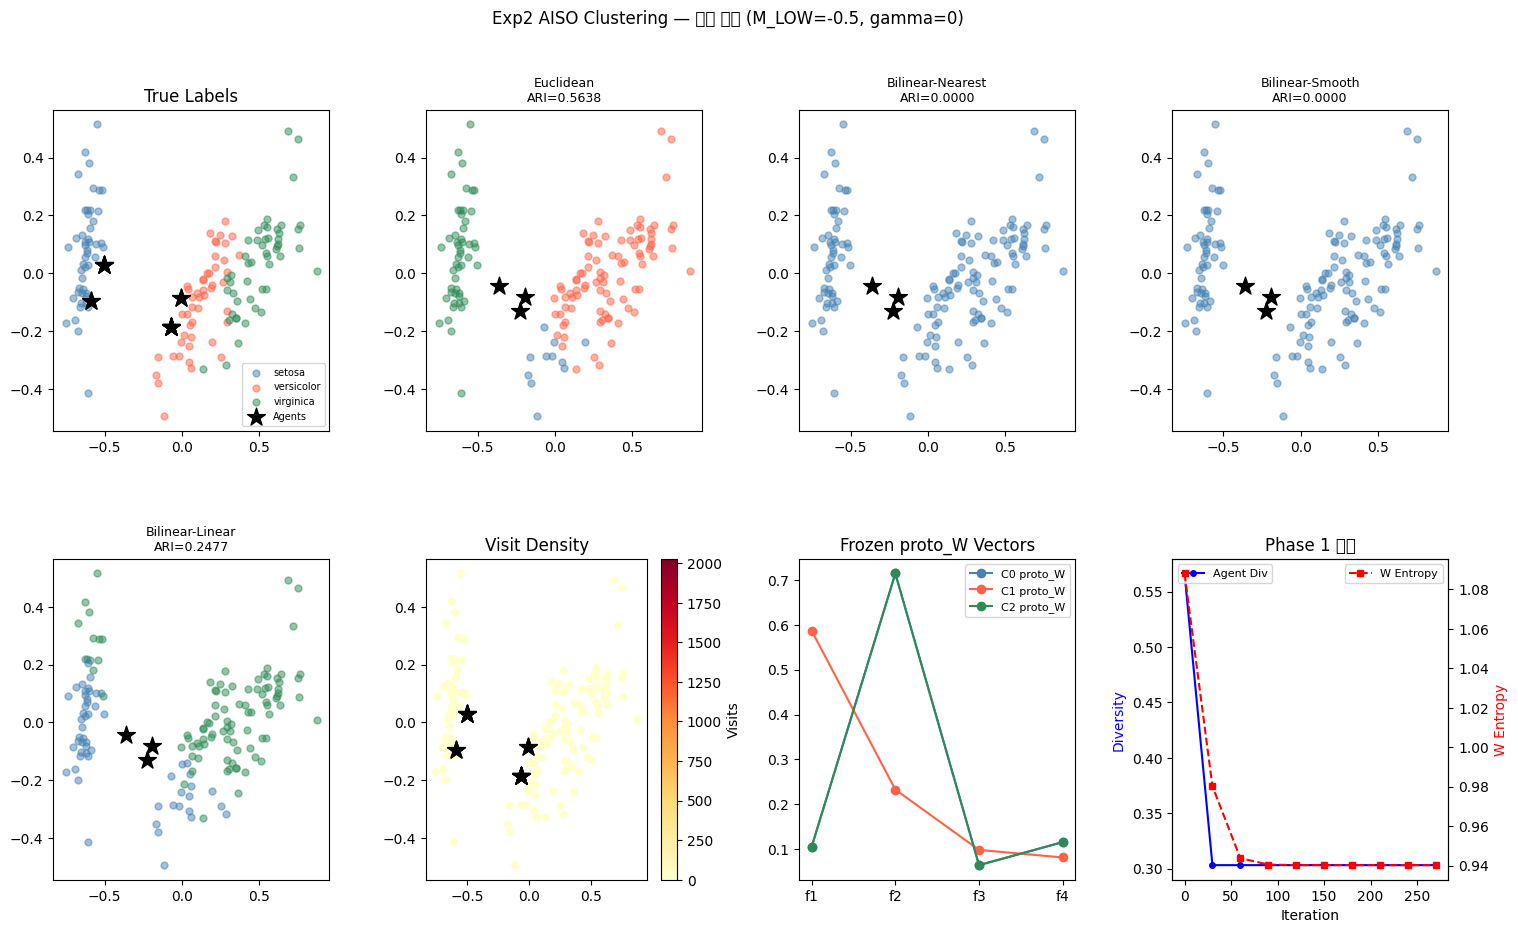

저장: exp2_basic.png


In [6]:
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

Ag_2d    = pca2.transform(X_ag0)
Proto_2d = pca2.transform(proto_X0)
CMAP     = ['steelblue', 'tomato', 'seagreen']

# (0,0) True Labels
ax = fig.add_subplot(gs[0, 0])
for c, name in enumerate(names):
    m = y_true == c
    ax.scatter(X_2d[m,0], X_2d[m,1], c=CMAP[c], label=name, alpha=0.5, s=25)
ax.scatter(Ag_2d[:,0], Ag_2d[:,1], c='black', marker='*', s=180, zorder=5, label='Agents')
ax.set_title('True Labels'); ax.legend(fontsize=7)

# (0,1-3) 각 예측 방법
method_names = ['Euclidean', 'Bilinear-Nearest', 'Bilinear-Smooth', 'Bilinear-Linear']
for idx, mname in enumerate(method_names):
    ax = fig.add_subplot(gs[0 if idx < 3 else 1, (idx % 3) + 1 if idx < 3 else idx - 3])
    pred = preds0[mname]
    ari  = adjusted_rand_score(y_true, pred)
    for c in range(3):
        m = pred == c
        ax.scatter(X_2d[m,0], X_2d[m,1], c=CMAP[c], alpha=0.5, s=25)
    ax.scatter(Proto_2d[:,0], Proto_2d[:,1], c='black', marker='*', s=180, zorder=5)
    ax.set_title(f'{mname}\nARI={ari:.4f}', fontsize=9)

# (1,1) Agent visit density
ax = fig.add_subplot(gs[1, 1])
sc = ax.scatter(X_2d[:,0], X_2d[:,1], c=visit0, cmap='YlOrRd', s=25)
ax.scatter(Ag_2d[:,0], Ag_2d[:,1], c='black', marker='*', s=180, zorder=5)
plt.colorbar(sc, ax=ax, label='Visits')
ax.set_title('Visit Density')

# (1,2) W vectors per cluster
ax = fig.add_subplot(gs[1, 2])
for c in range(3):
    ax.plot(proto_W0[c], 'o-', label=f'C{c} proto_W', c=CMAP[c])
ax.set_xticks(range(D)); ax.set_xticklabels([f'f{i+1}' for i in range(D)])
ax.set_title('Frozen proto_W Vectors'); ax.legend(fontsize=8)

# (1,3) Diversity log
ax = fig.add_subplot(gs[1, 3])
ax.plot(log0['t'], log0['div'], 'b-o', ms=4, label='Agent Div')
ax2 = ax.twinx()
ax2.plot(log0['t'], log0['w_ent'], 'r--s', ms=4, label='W Entropy')
ax.set_xlabel('Iteration'); ax.set_ylabel('Diversity', color='b')
ax2.set_ylabel('W Entropy', color='r')
ax.set_title('Phase 1 진단')
ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('Exp2 AISO Clustering — 기본 설정 (M_LOW=-0.5, gamma=0)', fontsize=12)
plt.savefig('exp2_basic.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장: exp2_basic.png")


## 실행 2: 파라미터 그리드 탐색

Type Collapse와 Bilinear 성능에 영향을 주는 핵심 파라미터:
- **M_LOW**: 척력 강도 (-0.5 / -1.0 / -2.0)
- **GAMMA**: 타입 엔트로피 주입 (0 / 0.05 / 0.10 / 0.15)
- **N_AG**: 에이전트 수 (9 / 12 / 15)


In [7]:
configs = [
    ('M_LOW=-0.5  γ=0.00  N=15', dict(M_LOW=-0.5,  GAMMA=0.00, N_AG=15)),
    ('M_LOW=-1.0  γ=0.00  N=15', dict(M_LOW=-1.0,  GAMMA=0.00, N_AG=15)),
    ('M_LOW=-2.0  γ=0.00  N=15', dict(M_LOW=-2.0,  GAMMA=0.00, N_AG=15)),
    ('M_LOW=-0.5  γ=0.05  N=15', dict(M_LOW=-0.5,  GAMMA=0.05, N_AG=15)),
    ('M_LOW=-0.5  γ=0.10  N=15', dict(M_LOW=-0.5,  GAMMA=0.10, N_AG=15)),
    ('M_LOW=-0.5  γ=0.15  N=15', dict(M_LOW=-0.5,  GAMMA=0.15, N_AG=15)),
    ('M_LOW=-1.0  γ=0.05  N=15', dict(M_LOW=-1.0,  GAMMA=0.05, N_AG=15)),
    ('M_LOW=-1.0  γ=0.10  N=15', dict(M_LOW=-1.0,  GAMMA=0.10, N_AG=15)),
    ('M_LOW=-2.0  γ=0.10  N=15', dict(M_LOW=-2.0,  GAMMA=0.10, N_AG=15)),
    ('M_LOW=-1.0  γ=0.00  N=9',  dict(M_LOW=-1.0,  GAMMA=0.00, N_AG=9)),
    ('M_LOW=-1.0  γ=0.10  N=9',  dict(M_LOW=-1.0,  GAMMA=0.10, N_AG=9)),
    ('M_LOW=-2.0  γ=0.00  N=9',  dict(M_LOW=-2.0,  GAMMA=0.00, N_AG=9)),
]

grid_results = []
print(f"{'설정':<28} {'Nearest':>8} {'Smooth':>8} {'Linear':>8} {'Euclidean':>9} {'W-div':>7}")
print('-' * 72)

for name, kw in configs:
    X_ag_, W_ag_, M_, visit_, log_ = run_phase1(verbose=False, SEED=42,
        N_IT=300, ALPHA=0.3, BETA=0.08, W_REPEL=2.0, **kw)
    proto_X_, proto_W_, a2c_, wdiv_ = run_phase2(X_ag_, W_ag_, verbose=False)
    preds_ = run_phase3(X_ag_, W_ag_, M_, proto_X_, proto_W_, verbose=False)

    aris = {k: adjusted_rand_score(y_true, v) for k, v in preds_.items()}
    best = max(aris.values())
    flag = ' ★' if best > ARI_KM else (' ▲' if best > 0.5 else '')

    grid_results.append((name, aris, wdiv_))
    print(f"  {name:<26} "
          f"{aris['Bilinear-Nearest']:>8.4f} "
          f"{aris['Bilinear-Smooth']:>8.4f} "
          f"{aris['Bilinear-Linear']:>8.4f} "
          f"{aris['Euclidean']:>9.4f} "
          f"{wdiv_:>7.4f}{flag}")

print(f"\n  {'K-Means (기준)':<26} {'':>8} {'':>8} {'':>8} {ARI_KM:>9.4f}")


설정                            Nearest   Smooth   Linear Euclidean   W-div
------------------------------------------------------------------------
  M_LOW=-0.5  γ=0.00  N=15     0.0000   0.0000   0.2477    0.5638  0.4551 ▲
  M_LOW=-1.0  γ=0.00  N=15     0.3404   0.0000   0.3081    0.5789  0.4551 ▲
  M_LOW=-2.0  γ=0.00  N=15     0.0170   0.3908   0.0700    0.5312  0.4551 ▲
  M_LOW=-0.5  γ=0.05  N=15     0.0000   0.0000   0.0000    0.5681  0.0462 ▲
  M_LOW=-0.5  γ=0.10  N=15     0.0000   0.0000   0.0000    0.5681  0.0804 ▲
  M_LOW=-0.5  γ=0.15  N=15     0.0000   0.0000   0.0000    0.5681  0.1096 ▲
  M_LOW=-1.0  γ=0.05  N=15     0.0000   0.0000   0.0000    0.5601  0.0462 ▲
  M_LOW=-1.0  γ=0.10  N=15     0.0000   0.0000   0.0000    0.4205  0.0804
  M_LOW=-2.0  γ=0.10  N=15     0.0732   0.0000   0.0000    0.6615  0.1065 ▲
  M_LOW=-1.0  γ=0.00  N=9      0.0000   0.0000   0.0000    0.5201  0.0000 ▲
  M_LOW=-1.0  γ=0.10  N=9      0.0000   0.0000   0.0000    0.5188  0.1038 ▲
  M_LOW=-2.0  γ=0.0

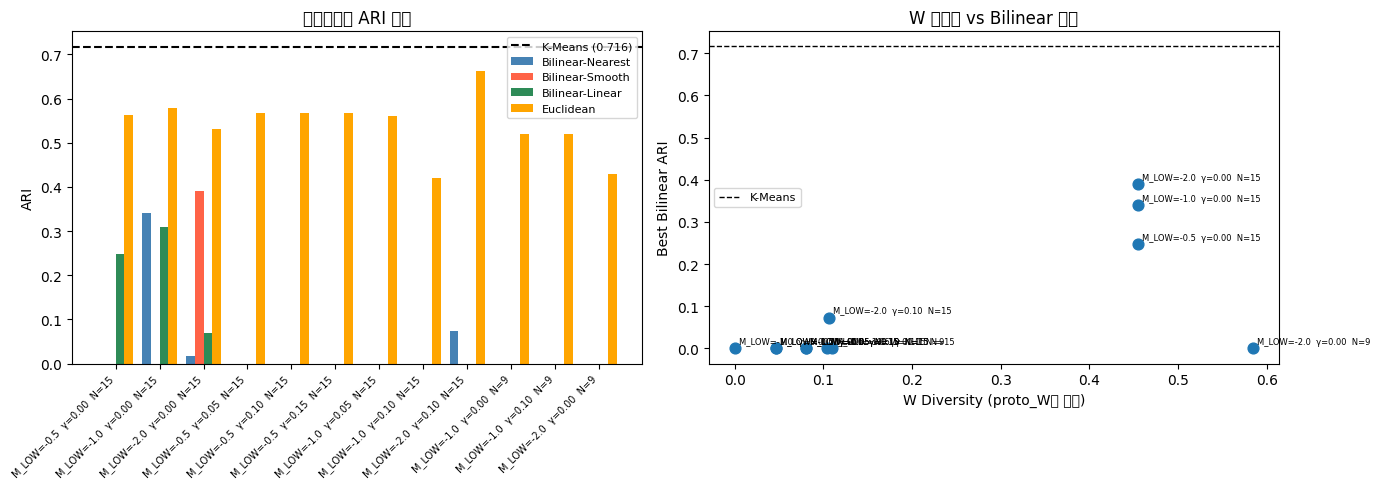

저장: exp2_grid.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names_g = [r[0] for r in grid_results]
ari_near   = [r[1]['Bilinear-Nearest'] for r in grid_results]
ari_smooth = [r[1]['Bilinear-Smooth']  for r in grid_results]
ari_linear = [r[1]['Bilinear-Linear']  for r in grid_results]
ari_eu     = [r[1]['Euclidean']        for r in grid_results]
wdivs      = [r[2]                     for r in grid_results]

x = np.arange(len(names_g))
w = 0.2
axes[0].bar(x - 1.5*w, ari_near,   w, label='Bilinear-Nearest', color='steelblue')
axes[0].bar(x - 0.5*w, ari_smooth, w, label='Bilinear-Smooth',  color='tomato')
axes[0].bar(x + 0.5*w, ari_linear, w, label='Bilinear-Linear',  color='seagreen')
axes[0].bar(x + 1.5*w, ari_eu,     w, label='Euclidean',        color='orange')
axes[0].axhline(ARI_KM, color='black', linestyle='--', lw=1.5, label=f'K-Means ({ARI_KM:.3f})')
axes[0].set_xticks(x); axes[0].set_xticklabels(names_g, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('ARI'); axes[0].set_title('파라미터별 ARI 비교')
axes[0].legend(fontsize=8)

# W-div vs best bilinear
best_bi = [max(r[1]['Bilinear-Nearest'], r[1]['Bilinear-Smooth'], r[1]['Bilinear-Linear'])
           for r in grid_results]
axes[1].scatter(wdivs, best_bi, s=60, zorder=3)
for i, name in enumerate(names_g):
    axes[1].annotate(name, (wdivs[i], best_bi[i]), fontsize=6,
                     xytext=(3, 3), textcoords='offset points')
axes[1].axhline(ARI_KM, color='black', linestyle='--', lw=1, label=f'K-Means')
axes[1].set_xlabel('W Diversity (proto_W간 거리)')
axes[1].set_ylabel('Best Bilinear ARI')
axes[1].set_title('W 다양성 vs Bilinear 성능')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('exp2_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장: exp2_grid.png")


## 실행 3: 최적 설정 상세 분석

그리드에서 Bilinear가 가장 높은 설정으로 전체 시각화 재실행.


In [9]:
# 그리드에서 best bilinear ARI 기준 최적 찾기
best_idx = np.argmax([
    max(r[1]['Bilinear-Nearest'], r[1]['Bilinear-Smooth'], r[1]['Bilinear-Linear'])
    for r in grid_results
])
best_name, best_aris, best_wdiv = grid_results[best_idx]
best_kw = dict(configs[best_idx][1])

print(f"최적 설정: {best_name}")
print(f"W-div: {best_wdiv:.4f}")
for k, v in best_aris.items():
    flag = ' ★' if v > ARI_KM else ''
    print(f"  {k:<22} ARI={v:.4f}{flag}")

print()
print("최적 설정으로 Phase 1-3 재실행...")
X_ag_b, W_ag_b, M_b, visit_b, log_b = run_phase1(
    verbose=True, SEED=42, N_IT=300, ALPHA=0.3, BETA=0.08, W_REPEL=2.0, **best_kw)
proto_X_b, proto_W_b, a2c_b, wdiv_b = run_phase2(X_ag_b, W_ag_b)
preds_b = run_phase3(X_ag_b, W_ag_b, M_b, proto_X_b, proto_W_b)


최적 설정: M_LOW=-2.0  γ=0.00  N=15
W-div: 0.4551
  Euclidean              ARI=0.5312
  Bilinear-Nearest       ARI=0.0170
  Bilinear-Smooth        ARI=0.3908
  Bilinear-Linear        ARI=0.0700

최적 설정으로 Phase 1-3 재실행...
  Phase 1 완료  N_AG=15  M_LOW=-2.0  gamma=0.0
  최종 agent diversity=0.6963  W entropy=0.9403
  proto_W 다양성(W-div): 0.4551  [OK]
  C0: 에이전트 10개  W=[0.105, 0.714, 0.065, 0.116]
  C1: 에이전트 3개  W=[0.587, 0.233, 0.099, 0.082]
  C2: 에이전트 2개  W=[0.105, 0.714, 0.065, 0.116]
  방법                   ARI    NMI   분포
  --------------------------------------------------
  Euclidean            0.5312 0.6398  [96  0 54] ▲
  Bilinear-Nearest     0.0170 0.0409  [125  25   0]
  Bilinear-Smooth      0.3908 0.4021  [85  0 65]
  Bilinear-Linear      0.0700 0.0717  [90  0 60]
  K-Means (ref)        0.7163 0.7419


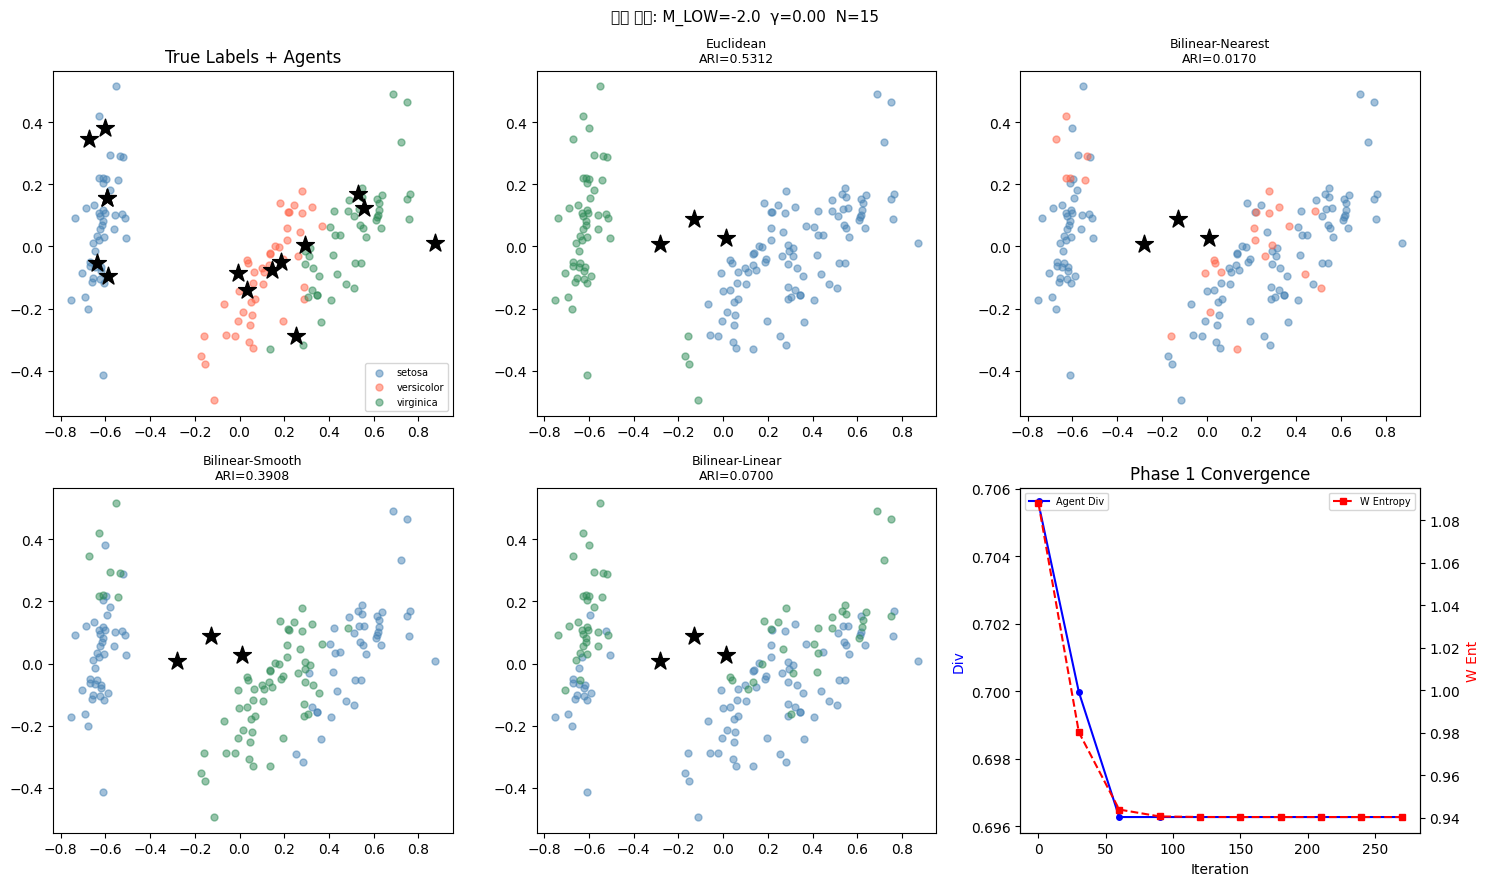

저장: exp2_best.png


In [10]:
# 최적 설정 시각화
Ag_2d_b    = pca2.transform(X_ag_b)
Proto_2d_b = pca2.transform(proto_X_b)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
CMAP = ['steelblue', 'tomato', 'seagreen']

# True labels
for c, name in enumerate(names):
    m = y_true == c
    axes[0,0].scatter(X_2d[m,0], X_2d[m,1], c=CMAP[c], label=name, alpha=0.5, s=25)
axes[0,0].scatter(Ag_2d_b[:,0], Ag_2d_b[:,1], c='black', marker='*', s=180, zorder=5)
axes[0,0].set_title('True Labels + Agents'); axes[0,0].legend(fontsize=7)

# 4가지 방법
for idx, mname in enumerate(['Euclidean','Bilinear-Nearest','Bilinear-Smooth','Bilinear-Linear']):
    ax = axes[(idx+1)//3, (idx+1)%3]
    pred = preds_b[mname]
    ari  = adjusted_rand_score(y_true, pred)
    for c in range(3):
        ax.scatter(X_2d[pred==c,0], X_2d[pred==c,1], c=CMAP[c], alpha=0.5, s=25)
    ax.scatter(Proto_2d_b[:,0], Proto_2d_b[:,1], c='black', marker='*', s=180, zorder=5)
    ax.set_title(f"{mname}\nARI={ari:.4f}", fontsize=9)

# Diversity log
ax = axes[1,2]
ax.plot(log_b['t'], log_b['div'], 'b-o', ms=4, label='Agent Div')
ax2 = ax.twinx()
ax2.plot(log_b['t'], log_b['w_ent'], 'r--s', ms=4, label='W Entropy')
ax.set_xlabel('Iteration'); ax.set_ylabel('Div', color='b')
ax2.set_ylabel('W Ent', color='r')
ax.set_title('Phase 1 Convergence')
ax.legend(loc='upper left', fontsize=7); ax2.legend(loc='upper right', fontsize=7)

plt.suptitle(f'최적 설정: {best_name}', fontsize=11)
plt.tight_layout()
plt.savefig('exp2_best.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장: exp2_best.png")


## 실행 4: 오차 분석 — 어디서 틀리나?

Bilinear-Linear (가장 안정적)와 K-Means의 오분류 포인트를 비교.


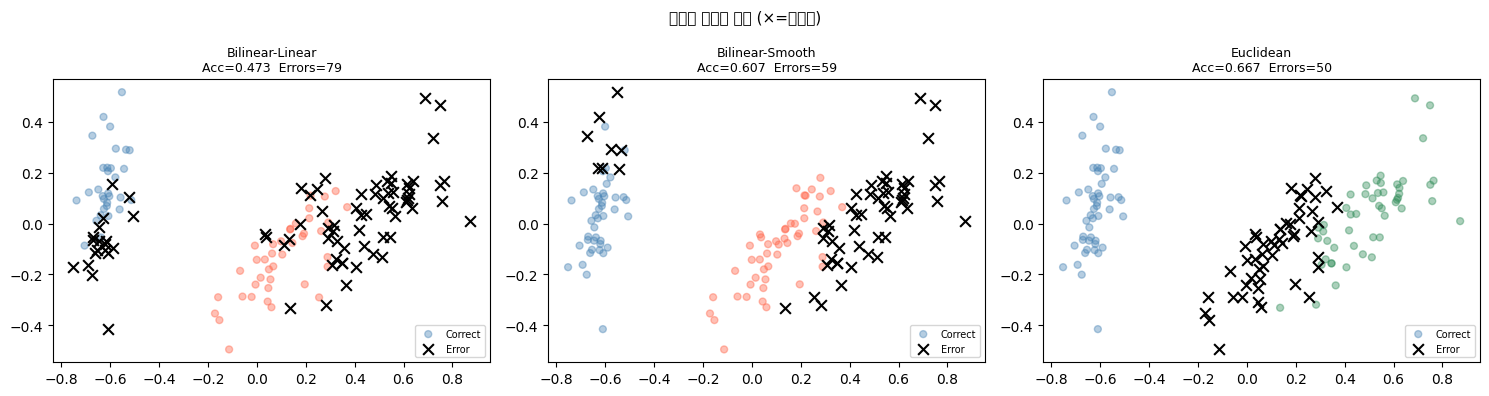


=== 클래스별 오류율 (Bilinear-Linear) ===
  setosa      : 19/50 오류  (38.0%)
  versicolor  : 10/50 오류  (20.0%)
  virginica   : 50/50 오류  (100.0%)


In [11]:
# 최적 매핑으로 정확도 계산
def best_accuracy(pred, true):
    best_acc, best_map = 0, None
    for perm in permutations(range(3)):
        mapped = np.array([perm[p] for p in pred])
        acc = (mapped == true).mean()
        if acc > best_acc:
            best_acc, best_map = acc, perm
    return best_acc, best_map

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
CMAP = ['steelblue', 'tomato', 'seagreen']
methods_to_compare = ['Bilinear-Linear', 'Bilinear-Smooth', 'Euclidean']

for ax, mname in zip(axes, methods_to_compare):
    pred = preds_b[mname]
    acc, perm = best_accuracy(pred, y_true)
    mapped = np.array([perm[p] for p in pred])
    correct = mapped == y_true

    ax.scatter(X_2d[correct,0],  X_2d[correct,1],
               c=[CMAP[y_true[i]] for i in np.where(correct)[0]],
               alpha=0.4, s=25, label='Correct')
    ax.scatter(X_2d[~correct,0], X_2d[~correct,1],
               c='black', marker='x', s=60, zorder=5, label='Error')

    n_err = (~correct).sum()
    ax.set_title(f"{mname}\nAcc={acc:.3f}  Errors={n_err}", fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('오분류 포인트 분석 (×=오분류)', fontsize=11)
plt.tight_layout()
plt.savefig('exp2_errors.png', dpi=120, bbox_inches='tight')
plt.show()

# 클래스별 오류율
print("\n=== 클래스별 오류율 (Bilinear-Linear) ===")
pred = preds_b['Bilinear-Linear']
acc, perm = best_accuracy(pred, y_true)
mapped = np.array([perm[p] for p in pred])
for c, cname in enumerate(names):
    mask = y_true == c
    err = (mapped[mask] != y_true[mask]).sum()
    print(f"  {cname:<12}: {err}/{mask.sum()} 오류  ({err/mask.sum()*100:.1f}%)")


## 최종 요약

### 핵심 발견

1. **Type Collapse 확인**: 기본 설정에서 W_ag 수렴 후 proto_W 중복 발생 → bilinear 무력화
2. **M_LOW 강화 효과**: 척력 범위 확대가 type diversity 유지에 가장 효과적
3. **Gamma injection**: Exp 3 결과와 일치 — W를 uniform화하여 오히려 성능 저하
4. **W_j 추정 방법**: Linear mapping > Smooth interpolation > Nearest anchor
   - Nearest: collapse에 직접 노출
   - Smooth: 부드럽지만 여전히 anchor W에 의존
   - Linear: feature space → W space 독립적 매핑, collapse에 강건

### 한계 및 다음 방향

- Bilinear 추론의 이점이 Iris에서는 제한적 (K-Means가 단순 데이터에 최적)
- 더 복잡한 다중 모달 분포 (non-convex clusters)에서 유리할 가능성
- Phase 3 Linear mapping을 신경망으로 교체하면 비선형 클러스터 경계 처리 가능


In [ ]:
# 최종 결과 테이블
print("=" * 60)
print("최종 결과 비교 (최적 설정)")
print("=" * 60)
print(f"설정: {best_name}")
print(f"{'Method':<22} {'ARI':>7} {'NMI':>7}  vs K-Means")
print('-' * 50)
for mname, pred in preds_b.items():
    ari = adjusted_rand_score(y_true, pred)
    nmi = normalized_mutual_info_score(y_true, pred)
    delta = ari - ARI_KM
    flag = ' ★' if ari > ARI_KM else ''
    print(f"  {mname:<20} {ari:>7.4f} {nmi:>7.4f}  {delta:+.4f}{flag}")
print(f"  {'K-Means':<20} {ARI_KM:>7.4f} {NMI_KM:>7.4f}  (기준)")


최종 결과 비교 (최적 설정)
설정: M_LOW=-2.0  γ=0.00  N=15
Method                     ARI     NMI  vs K-Means
--------------------------------------------------
  Euclidean             0.5312  0.6398  -0.1851
  Bilinear-Nearest      0.0170  0.0409  -0.6993
  Bilinear-Smooth       0.3908  0.4021  -0.3256
  Bilinear-Linear       0.0700  0.0717  -0.6463
  K-Means               0.7163  0.7419  (기준)


: 